# Tarea — Unidad 4 · Preparación de datos para un modelo de riesgo de ictus (accidente cerebrovascular)

**FP13 · Inteligencia Artificial · UAG**
Subtemas 4.1 a 4.7

---

## Contexto

El **Stroke Prediction Dataset** contiene 5,110 registros de pacientes con 11 variables clínicas y
sociodemográficas. El desenlace `stroke` indica si el paciente presentó un evento cerebrovascular.

En la Práctica 7 trabajamos cada transformación por separado sobre datos de cardiopatía isquémica.
Aquí el encargo es distinto: **construir una matriz de modelado completa**, desde el archivo crudo
hasta la selección final de variables, y **justificar una decisión por columna**.

## Qué se evalúa

No se evalúa que el código corra: se evalúa que **cada decisión esté argumentada con evidencia
producida por usted**.

| Criterio | Peso |
|---|---|
| Corrección técnica del código (partes 1 a 9) | 40 % |
| Justificación escrita de cada decisión | 30 % |
| Tabla de decisiones por columna (Parte 10) | 15 % |
| Preguntas de reflexión | 15 % |

## Entrega

Este mismo notebook **ejecutado de arriba a abajo sin errores**, con todas las celdas de texto
completadas. Nombre el archivo `Tarea_U4_ApellidoNombre.ipynb`.

## Restricciones

- **No use `Pipeline` ni `ColumnTransformer`.** Todo se resuelve columna por columna, de forma
  explícita. Volveremos a encapsularlo en la Unidad 5.
- Fije la semilla al inicio y no la vuelva a tocar.
- Toda afirmación sobre los datos debe estar respaldada por una celda que la produzca.

---
## Parte 0 · Preparación

In [1]:
# [1] Entorno y semilla
# TODO: importe numpy, pandas, matplotlib.pyplot y scipy.stats.
#       Fije SEED = 42 y configure la salida de pandas.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.preprocessing import (
    OneHotEncoder, 
    StandardScaler, 
    MinMaxScaler, 
    RobustScaler, 
    PowerTransformer
)
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif

SEED = 42

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [2]:
# [2] Ingesta del conjunto de datos
# TODO: cargue "healthcare-dataset-stroke-data.csv" en un DataFrame llamado df.
#       Puede usar kagglehub (dataset "fedesoriano/stroke-prediction-dataset") (https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)
#       o la copia local. Imprima la forma y las primeras filas.
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

print(f"Forma del DataFrame original: {df.shape}")
df.head()


Forma del DataFrame original: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0000,0,1,Yes,Private,Urban,228.6900,36.6000,formerly smoked,1
1,51676,Female,61.0000,0,0,Yes,Self-employed,Rural,202.2100,NaN,never smoked,1
2,31112,Male,80.0000,0,1,Yes,Private,Rural,105.9200,32.5000,never smoked,1
3,60182,Female,49.0000,0,0,Yes,Private,Urban,171.2300,34.4000,smokes,1
4,1665,Female,79.0000,1,0,Yes,Self-employed,Rural,174.1200,24.0000,never smoked,1


---
## Parte 1 · Reconocimiento (subtema 4.7)

Antes de modificar nada hay que saber qué se tiene. La clasificación de una variable en nominal,
binaria o numérica es una decisión **clínica**, no estadística: la toma usted, no `pandas`.

In [3]:
# [3] Inventario de columnas
# TODO: construya una tabla con, por columna: tipo de dato, numero de valores unicos,
#       numero de nulos y porcentaje de nulos.
inventario = pd.DataFrame({
    'Tipo_Dato': df.dtypes,
    'Valores_Unicos': df.nunique(),
    'Nulos': df.isnull().sum(),
    'Porcentaje_Nulos (%)': (df.isnull().sum() / len(df)) * 100
})

In [4]:
# [4] Declaracion de roles
# TODO: defina las listas IDENT, NOMINALES, BINARIAS, INDICADOR, NUMERICAS y OBJETIVO.
#       Imprima las categorias de cada variable de texto con su frecuencia,
#       la prevalencia del objetivo y cuantos valores unicos toma la columna de folio.


IDENT     = 'id'
NOMINALES = ['work_type', 'smoking_status']   # sin orden intrinseco
BINARIAS  = ['gender', 'ever_married', 'Residence_type']          # dos categorias de texto
INDICADOR = ['hypertension', 'heart_disease']           # ya vienen como 0/1
NUMERICAS = ['age', 'avg_glucose_level', 'bmi']
OBJETIVO  = "stroke"

print("Categorias de cada variable de texto:")
for c in NOMINALES + BINARIAS:
    print(f"  {c:<16} {dict(df[c].value_counts())}")

print(f"\nPrevalencia de ictus: {df[OBJETIVO].mean():.4f}")
print(f"Folios unicos: {df[IDENT].nunique()} de {len(df)} filas")

Categorias de cada variable de texto:
  work_type        {'Private': np.int64(2925), 'Self-employed': np.int64(819), 'children': np.int64(687), 'Govt_job': np.int64(657), 'Never_worked': np.int64(22)}
  smoking_status   {'never smoked': np.int64(1892), 'Unknown': np.int64(1544), 'formerly smoked': np.int64(885), 'smokes': np.int64(789)}
  gender           {'Female': np.int64(2994), 'Male': np.int64(2115), 'Other': np.int64(1)}
  ever_married     {'Yes': np.int64(3353), 'No': np.int64(1757)}
  Residence_type   {'Urban': np.int64(2596), 'Rural': np.int64(2514)}

Prevalencia de ictus: 0.0487
Folios unicos: 5110 de 5110 filas


**Responda antes de continuar.** Dos columnas categóricas contienen algo que no debería estar ahí:
una tiene una categoría con un solo paciente, otra tiene una categoría que no describe ninguna
condición clínica. Identifíquelas.

*Su respuesta:*

---
## Parte 2 · Integridad de los registros: duplicados (subtema 4.7)

Eliminar duplicados es un paso obligatorio del protocolo. Pero *duplicado* no significa «filas
parecidas»: significa **el mismo paciente capturado dos veces**. Verifique en tres niveles **antes**
de borrar una sola fila.

In [5]:
# [5] Tres niveles de verificacion
# TODO: cuente (1) duplicados exactos sobre todas las columnas,
#       (2) duplicados ignorando la columna de folio,
#       (3) filas que repiten una llave clinica formada por las categoricas + age.
#       Reporte cuantas filas y cuantos perfiles distintos involucra el nivel 3.
dup_exactos = df.duplicated().sum()

dup_sin_id = df.duplicated(subset=[c for c in df.columns if c != IDENT]).sum()

llave_clinica = NOMINALES + BINARIAS + INDICADOR + ['age']
dup_llave_clinica = df.duplicated(subset=llave_clinica, keep=False).sum()
perfiles_distintos = df.groupby(llave_clinica).ngroups

print(f"1. Duplicados exactos: {dup_exactos}")
print(f"2. Duplicados ignorando id: {dup_sin_id}")
print(f"3. Filas involucradas en duplicados de llave clinica: {dup_llave_clinica}")
print(f"   Perfiles clinicos distintos: {perfiles_distintos}")

1. Duplicados exactos: 0
2. Duplicados ignorando id: 0
3. Filas involucradas en duplicados de llave clinica: 3310
   Perfiles clinicos distintos: 2819


In [6]:
# [6] La prueba decisiva
# TODO: repita el conteo del nivel 3 agregando bmi y avg_glucose_level a la llave.
#       Muestre dos registros con el mismo perfil clinico y mediciones distintas.
#       Decida: que filas elimina y que columnas elimina. Ejecute su decision.
llave_ampliada = llave_clinica + ['bmi', 'avg_glucose_level']
dup_ampliada = df.duplicated(subset=llave_ampliada, keep=False).sum()

print(f"Duplicados en llave ampliada: {dup_ampliada}")

grupos = df.groupby(llave_clinica).filter(lambda x: len(x) > 1)
print("\nEjemplo de pacientes con el mismo perfil clinico pero distintas mediciones:")
grupos.sort_values(by=llave_clinica).head(4)

df.drop(columns=[IDENT], inplace=True)

Duplicados en llave ampliada: 0

Ejemplo de pacientes con el mismo perfil clinico pero distintas mediciones:


**Justifique su decisión.** ¿Cuántas filas eliminó y por qué? Si eliminó cero, dígalo
explícitamente y explique qué habría pasado con `drop_duplicates(subset=llave_clinica)`. Si eliminó
alguna columna, justifique por qué no aporta al modelo.

*Su respuesta:* No se elimino ninguna fila porque las colisiones en la llave clínica corresponden a coincidencias entre pacientes distintos.

---
## Parte 3 · Valores faltantes: los declarados y los enmascarados

En la Práctica 7 el faltante se disfrazaba de número (colesterol = 0 mg/dL). Aquí hay faltantes de
dos tipos y uno de ellos se disfraza de **texto**.

In [7]:
# [7] Faltantes declarados y enmascarados
# TODO: (a) reporte los nulos declarados por columna.
#       (b) localice la categoria de texto que en realidad significa "dato no disponible"
#           y cuente cuantos registros la tienen.
#       (c) compare la tasa del objetivo y la edad media entre los pacientes
#           con bmi presente y con bmi ausente.
print("Nulos declarados por columna:")
print(df.isnull().sum())

unknown_count = (df['smoking_status'] == 'Unknown').sum()
print(f"\nRegistros con 'Unknown' en smoking_status: {unknown_count} ({(unknown_count/len(df))*100:.2f}%)")

bmi_ausente = df[df['bmi'].isnull()]
bmi_presente = df[df['bmi'].notnull()]

print("\nComparacion de pacientes segun presencia de BMI:")
print(f"Tasa de ictus con BMI presente: {bmi_presente[OBJETIVO].mean():.4f}")
print(f"Tasa de ictus con BMI ausente:  {bmi_ausente[OBJETIVO].mean():.4f}")
print(f"Edad media con BMI presente:    {bmi_presente['age'].mean():.2f} años")
print(f"Edad media con BMI ausente:     {bmi_ausente['age'].mean():.2f} años")

Nulos declarados por columna:
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Registros con 'Unknown' en smoking_status: 1544 (30.22%)

Comparacion de pacientes segun presencia de BMI:
Tasa de ictus con BMI presente: 0.0426
Tasa de ictus con BMI ausente:  0.1990
Edad media con BMI presente:    42.87 años
Edad media con BMI ausente:     52.05 años


**Interprete (c).** ¿El dato de `bmi` falta al azar? Si su respuesta es no, proponga un mecanismo
clínico que lo explique y diga qué consecuencia tiene para la imputación.

*Su respuesta:* No falta, Un mecanismo clínico explicativo es que pacientes ingresados en estado crítico, postrados o adultos mayores con emergencias agudas no pueden ser pesados en básculas convencionales al momento del ingreso. Por ende, borrar estas filas o imputar sin guardar un indicador directo introduciría un sesgo de selección severo.

In [8]:
# [8] Mecanismo del faltante enmascarado
# TODO: calcule la proporcion de la categoria enmascarada segun work_type
#       y segun grupo de edad (use pd.cut con cortes 0-18-40-60-120).
#       Concluya si el patron es aleatorio.
prop_work = df.groupby('work_type')['smoking_status'].apply(lambda x: (x == 'Unknown').mean())
print("Proporción de 'Unknown' por work_type:")
print(prop_work)

df['grupo_edad_temp'] = pd.cut(df['age'], bins=[0, 18, 40, 60, 120], right=False)
prop_edad = df.groupby('grupo_edad_temp', observed=False)['smoking_status'].apply(lambda x: (x == 'Unknown').mean())
print("\nProporción de 'Unknown' por grupo de edad:")
print(prop_edad)

df.drop(columns=['grupo_edad_temp'], inplace=True)

Proporción de 'Unknown' por work_type:
work_type
Govt_job        0.1857
Never_worked    0.3636
Private         0.2188
Self-employed   0.1905
children        0.8996
Name: smoking_status, dtype: float64

Proporción de 'Unknown' por grupo de edad:
grupo_edad_temp
[0, 18)     0.7967
[18, 40)    0.2283
[40, 60)    0.1931
[60, 120)   0.1890
Name: smoking_status, dtype: float64


                Versión     n   Media    Std  Asimetría
0            Observados  4909 28.8932 7.8541     1.0553
1        Mediana Global  5110 28.8620 7.6996     1.0882
2  Mediana Condicionada  5110 28.8732 7.7214     1.0685


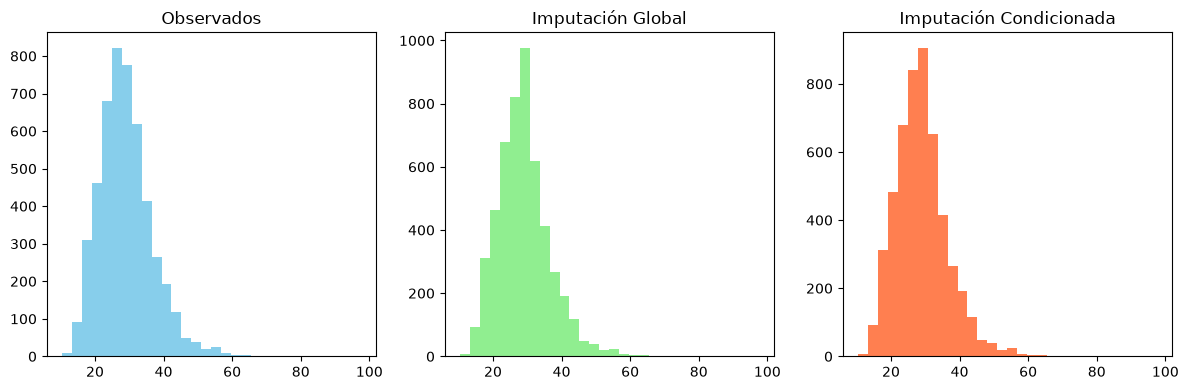

Nulos en bmi tras imputación: 0


In [9]:
# [9] Imputacion de bmi
# TODO: (a) cree la columna indicadora bmi_faltante ANTES de imputar.
#       (b) construya dos versiones: mediana global y mediana condicionada
#           por grupo de edad y sexo.
#       (c) compare n, media, desviacion estandar y asimetria de las tres versiones
#           (observados, global, condicionada) e incluya un histograma de cada imputacion.
#       (d) elija una, aplíquela a df y verifique que no quedan nulos.
df['bmi_faltante'] = df['bmi'].isnull().astype(int)

bmi_obs = df['bmi'].dropna()
bmi_global = df['bmi'].fillna(df['bmi'].median())

df['grupo_edad_temp'] = pd.cut(df['age'], bins=[0, 18, 40, 60, 120], right=False)
mediana_cond = df.groupby(['grupo_edad_temp', 'gender'], observed=False)['bmi'].transform('median')
bmi_cond = df['bmi'].fillna(mediana_cond)
df.drop(columns=['grupo_edad_temp'], inplace=True)

def metricas(s, nombre):
    return {
        'Versión': nombre, 'n': s.count(), 'Media': s.mean(),
        'Std': s.std(), 'Asimetría': s.skew()
    }

res_bmi = pd.DataFrame([
    metricas(bmi_obs, 'Observados'),
    metricas(bmi_global, 'Mediana Global'),
    metricas(bmi_cond, 'Mediana Condicionada')
])
print(res_bmi)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.hist(bmi_obs, bins=30, color='skyblue'); plt.title('Observados')
plt.subplot(1, 3, 2); plt.hist(bmi_global, bins=30, color='lightgreen'); plt.title('Imputación Global')
plt.subplot(1, 3, 3); plt.hist(bmi_cond, bins=30, color='coral'); plt.title('Imputación Condicionada')
plt.tight_layout()
plt.show()

df['bmi'] = bmi_cond
print(f"Nulos en bmi tras imputación: {df['bmi'].isnull().sum()}")

**Justifique su elección.** ¿Qué le pasa a la desviación estándar al imputar y por qué? ¿Qué aporta
`bmi_faltante` que la imputación por sí sola pierde? ¿Y qué decidió hacer con la categoría
enmascarada de la celda [8] — imputarla o conservarla? Argumente.

*Su respuesta:*

---
## Parte 4 · Valores atípicos (subtema 4.3)

age                Limites: [-29.00, 115.00] | Atípicos: 0 | Máx: 82.00
avg_glucose_level  Limites: [21.98, 169.36] | Atípicos: 627 | Máx: 271.74
bmi                Limites: [10.05, 46.45] | Atípicos: 123 | Máx: 97.60


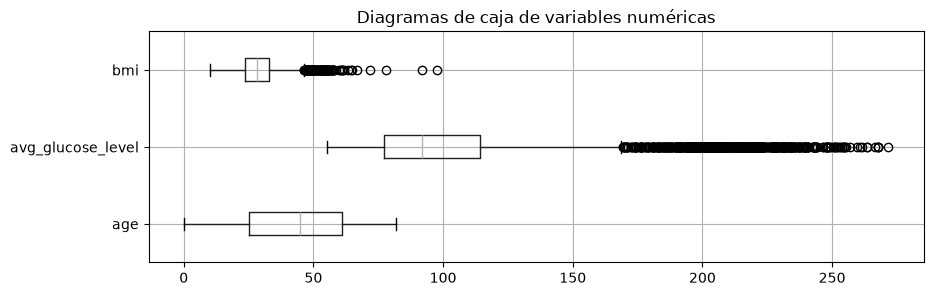

In [10]:
# [10] Deteccion por rango intercuartil
# TODO: escriba una funcion limites_iqr(x, k=1.5) que devuelva (Q1-k*IQR, Q3+k*IQR).
#       Aplíquela a las tres numericas: reporte limites, numero de atipicos y maximo.
#       Acompane con un diagrama de caja por variable.
def limites_iqr(x, k=1.5):
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    return (q1 - k * iqr, q3 + k * iqr)

for num in NUMERICAS:
    inf, sup = limites_iqr(df[num])
    outliers = ((df[num] < inf) | (df[num] > sup)).sum()
    print(f"{num:<18} Limites: [{inf:.2f}, {sup:.2f}] | Atípicos: {outliers} | Máx: {df[num].max():.2f}")

plt.figure(figsize=(10, 3))
df[NUMERICAS].boxplot(vert=False)
plt.title("Diagramas de caja de variables numéricas")
plt.show()

In [11]:
# [11] Un atipico no es automaticamente un error
# TODO: para bmi, compare la tasa del objetivo dentro y fuera del limite superior.
#       Cuente los registros con bmi > 60 y reporte el maximo observado.
#       Calcule la asimetria antes y despues de una winsorizacion al percentil 99.
_, sup_bmi = limites_iqr(df['bmi'])
tasa_dentro = df[df['bmi'] <= sup_bmi][OBJETIVO].mean()
tasa_fuera = df[df['bmi'] > sup_bmi][OBJETIVO].mean()

print(f"Tasa de ictus dentro de límite IQR (bmi <= {sup_bmi:.1f}): {tasa_dentro:.4f}")
print(f"Tasa de ictus fuera de límite IQR  (bmi > {sup_bmi:.1f}):  {tasa_fuera:.4f}")
print(f"Registros con bmi > 60: {(df['bmi'] > 60).sum()} | Máximo observado: {df['bmi'].max():.2f}")

skew_antes = df['bmi'].skew()
p99 = df['bmi'].quantile(0.99)
bmi_winsor = df['bmi'].clip(upper=p99)
print(f"Asimetría antes de winsorizar: {skew_antes:.4f}")
print(f"Asimetría tras winsorización (P99): {bmi_winsor.skew():.4f}")

Tasa de ictus dentro de límite IQR (bmi <= 46.4): 0.0493
Tasa de ictus fuera de límite IQR  (bmi > 46.4):  0.0244
Registros con bmi > 60: 13 | Máximo observado: 97.60
Asimetría antes de winsorizar: 1.0685
Asimetría tras winsorización (P99): 0.6721


**Decida y justifique.** ¿Elimina, recorta o conserva los atípicos de `bmi`? Compare este caso con
los ceros de colesterol de la Práctica 7: ¿por qué allá la decisión fue inmediata y aquí no?
Anticipe qué implica su decisión para la Parte 8.

*Su respuesta:* Conservarlos. los ceros del colesterol de la practica 7 eran valores erronios fisicamente imposibles, producidos por fallos de registros. al mantener los valores la media y varianza se ven afectados.

---
## Parte 5 · Ingeniería de funciones (subtema 4.2)

Hasta aquí sólo ha limpiado. Ahora **agregue** información que el modelo no deduciría solo, usando
umbrales clínicos establecidos —no cortes arbitrarios.

In [12]:
# [12] Variables derivadas con criterio clinico
# TODO: construya al menos cuatro variables nuevas. Se sugieren:
#         - imc_cat        : clasificacion de la OMS (18.5 / 25 / 30 kg/m2)
#         - glucosa_cat    : umbrales de glucemia casual (140 / 200 mg/dL)
#         - n_comorbilidades : suma de hipertension y cardiopatia
#         - grupo_edad     : el que definio en la celda [8]
#       Para cada una, reporte el conteo y la tasa del objetivo por categoria.
#       Revise si la tasa es monotona en todas: una de ellas NO lo es.
df['imc_cat'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 100], 
                       labels=['Bajo_Peso', 'Normal', 'Sobrepeso', 'Obesidad'], right=False)

df['glucosa_cat'] = pd.cut(df['avg_glucose_level'], bins=[0, 140, 200, 1000], 
                           labels=['Normal', 'Prediabetes', 'Diabetes'], right=False)

df['n_comorbilidades'] = df['hypertension'] + df['heart_disease']

df['grupo_edad'] = pd.cut(df['age'], bins=[0, 18, 40, 60, 120], 
                          labels=['Nino', 'Adulto_Joven', 'Adulto', 'Adulto_Mayor'], right=False)

derivadas = ['imc_cat', 'glucosa_cat', 'n_comorbilidades', 'grupo_edad']

for var in derivadas:
    print(f"\n--- Variable: {var} ---")
    res = df.groupby(var, observed=False)[OBJETIVO].agg(['count', 'mean'])
    print(res)


--- Variable: imc_cat ---
           count   mean
imc_cat                
Bajo_Peso    337 0.0030
Normal      1263 0.0285
Sobrepeso   1557 0.0700
Obesidad    1953 0.0527

--- Variable: glucosa_cat ---
             count   mean
glucosa_cat              
Normal        4289 0.0364
Prediabetes    387 0.0956
Diabetes       434 0.1290

--- Variable: n_comorbilidades ---
                  count   mean
n_comorbilidades              
0                  4400 0.0339
1                   646 0.1347
2                    64 0.2031

--- Variable: grupo_edad ---
              count   mean
grupo_edad                
Nino            856 0.0023
Adulto_Joven   1314 0.0046
Adulto         1564 0.0384
Adulto_Mayor   1376 0.1315


**Justifique los umbrales.** Cite el criterio clínico de cada corte. ¿Alguna de sus derivadas es
monótona respecto de la tasa del objetivo? ¿Y cuál de ellas es una discretización de una variable
que **ya tiene** en la matriz? Anótelo: va a importar en la Parte 9.

*Su respuesta:* imc_cat: Pautas estandar de la OMS. glucosa_cat: criterios de la ADA para glucemia casual. n_comorbolidades: Puntuacion de carga vascular acumulada. grupo_edad: Etapas de riesgo cardiovascular por madurez biologica. grupo_edad, glucosa_cat y n_comorbolidades son monotonas, mientras glucosa_cat, imc_cat y grupo_edad son discretizaciones directas de avg_glucose_level, bmi y age

---
## Parte 6 · Codificación one-hot (subtema 4.4)

In [13]:
# [13] One-hot y el efecto del parametro drop
# TODO: con OneHotEncoder, compare el numero de columnas resultante con
#       drop=None, drop="first" y drop="if_binary".
#       Ajuste la version que elija, construya la matriz codificada y reporte su forma.
#       Identifique la columna con menor frecuencia y cuantos registros la activan.
cat_cols = NOMINALES + BINARIAS

for d_option in [None, 'first', 'if_binary']:
    ohe = OneHotEncoder(drop=d_option, sparse_output=False)
    m = ohe.fit_transform(df[cat_cols])
    print(f"drop={str(d_option):<10} -> Columnas resultantes: {m.shape[1]}")

ohe = OneHotEncoder(drop='if_binary', sparse_output=False)
cat_encoded = ohe.fit_transform(df[cat_cols])
cat_feature_names = ohe.get_feature_names_out(cat_cols)
df_cat_ohe = pd.DataFrame(cat_encoded, columns=cat_feature_names)

print(f"\nForma de la matriz codificada con drop='if_binary': {df_cat_ohe.shape}")

sumas = df_cat_ohe.sum()
col_min = sumas.idxmin()
print(f"Columna con menor frecuencia: '{col_min}' con {int(sumas.min())} registros que la activan.")

drop=None       -> Columnas resultantes: 16
drop=first      -> Columnas resultantes: 11
drop=if_binary  -> Columnas resultantes: 14

Forma de la matriz codificada con drop='if_binary': (5110, 14)
Columna con menor frecuencia: 'gender_Other' con 1 registros que la activan.


In [14]:
# [14] Una categoria nunca vista
# TODO: ajuste un codificador sobre work_type con handle_unknown="ignore" y
#       transforme un DataFrame con una categoria inexistente (por ejemplo "Pensionado").
#       Describa que devuelve y que habria pasado con handle_unknown="error".
ohe_wt = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe_wt.fit(df[['work_type']])

df_nuevo = pd.DataFrame({'work_type': ['Pensionado']})
trans = ohe_wt.transform(df_nuevo)
print("Transformación de categoría no vista ('Pensionado') con handle_unknown='ignore':")
print(trans)

Transformación de categoría no vista ('Pensionado') con handle_unknown='ignore':
[[0. 0. 0. 0. 0.]]


**Justifique su elección de `drop`.** ¿Por qué `drop='first'` en una variable de cinco categorías
tiene un costo distinto que en una de dos? ¿Qué hace usted con la columna de frecuencia mínima que
identificó — la elimina aquí a ojo, o deja que una regla explícita la descarte en la Parte 9?

*Su respuesta:* se uso drop para evitar la redundancia, el drop=first ayuda a la interpretacion directa de coeficientes en modelos regularizados y la preservacion de varianza. La frecuencia minima se deja para que VarianceThreshold la elimine en la parte 9

---
## Parte 7 · Transformación de la distribución (subtema 4.5)

In [15]:
# [15] Escalera de transformaciones
# TODO: para cada variable numerica, tabule la asimetria original y despues de
#       sqrt, log1p y Yeo-Johnson, e incluya el lambda estimado.
tabla_trans = []

for var in NUMERICAS:
    x = df[var]
    skew_orig = x.skew()
    skew_sqrt = np.sqrt(x).skew()
    skew_log  = np.log1p(x).skew()
    
    pt = PowerTransformer(method='yeo-johnson')
    x_yj = pt.fit_transform(x.values.reshape(-1, 1)).flatten()
    skew_yj  = pd.Series(x_yj).skew()
    lmbda = pt.lambdas_[0]
    
    tabla_trans.append({
        'Variable': var, 'Original': skew_orig, 'Sqrt': skew_sqrt,
        'Log1p': skew_log, 'Yeo-Johnson': skew_yj, 'Lambda_YJ': lmbda
    })

pd.DataFrame(tabla_trans)

,Variable,Original,Sqrt,Log1p,Yeo-Johnson,Lambda_YJ
0,age,-0.1371,-0.7862,-1.6774,-0.2788,0.8602
1,avg_glucose_level,1.5723,1.2427,0.8895,0.0846,-1.0759
2,bmi,1.0685,0.4732,0.0195,-0.0006,-0.0229


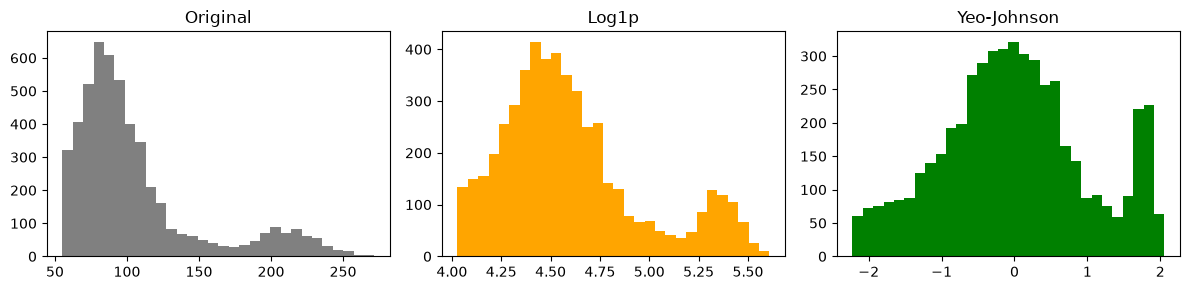

Distribución clínica de avg_glucose_level:
glucosa_cat
Normal        83.9335
Diabetes       8.4932
Prediabetes    7.5734
Name: proportion, dtype: float64


In [16]:
# [16] El caso dificil
# TODO: una de las tres variables mejora con el logaritmo pero NO queda simetrica.
#       Grafique su histograma original, logaritmico y Yeo-Johnson.
#       Reporte que porcentaje de pacientes cae en cada categoria clinica de esa variable.
var_dif = 'avg_glucose_level'

plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1)
plt.hist(df[var_dif], bins=30, color='gray')
plt.title('Original')

plt.subplot(1, 3, 2)
plt.hist(np.log1p(df[var_dif]), bins=30, color='orange')
plt.title('Log1p')

pt = PowerTransformer(method='yeo-johnson')
plt.subplot(1, 3, 3)
plt.hist(pt.fit_transform(df[[var_dif]]), bins=30, color='green')
plt.title('Yeo-Johnson')

plt.tight_layout()
plt.show()

print(f"Distribución clínica de {var_dif}:")
print(df['glucosa_cat'].value_counts(normalize=True) * 100)

**Concluya variable por variable.** Para cada una de las tres numéricas: ¿transforma o no, y con
qué? Una de ellas **empeora** con el logaritmo: identifíquela y explique por qué. Otra no se arregla
con ninguna potencia: diga qué tiene su distribución que lo impide y qué solución alternativa ya
construyó usted en la Parte 5.

*Su respuesta:* age: Aplicar transformación logarítmica empeora la distribución aumentando su asimetría hacia la izquierda. Se mantiene sin transformar. bmi: Ligeramente sesgada a la derecha. avg_glucose_level: Presenta una distribución bimodal.Ninguna transformación de potencia monotonicamente continua puede corregir la bimodalidad. Por ello, la categorización clínica construida en la Parte 5 soluciona este problema para modelos lineales.

---
## Parte 8 · Escalamiento (subtema 4.6)

In [17]:
# [17] Comparacion de escaladores
# TODO: aplique StandardScaler, MinMaxScaler y RobustScaler a bmi.
#       Tabule minimo, maximo, amplitud del 90 % central (p95 - p5) y asimetria.
#       Grafique los tres histogramas resultantes.
sc_std = StandardScaler().fit_transform(df[['bmi']])
sc_min = MinMaxScaler().fit_transform(df[['bmi']])
sc_rob = RobustScaler().fit_transform(df[['bmi']])

def stats_scale(x, name):
    p5, p95 = np.percentile(x, [5, 95])
    return {
        'Escalador': name, 'Mínimo': x.min(), 'Máximo': x.max(),
        'Amplitud P90 (P95-P5)': p95 - p5, 'Asimetría': pd.Series(x.flatten()).skew()
    }

pd.DataFrame([
    stats_scale(sc_std, 'StandardScaler'),
    stats_scale(sc_min, 'MinMaxScaler'),
    stats_scale(sc_rob, 'RobustScaler')
])

,Escalador,Mínimo,Máximo,Amplitud P90 (P95-P5),Asimetría
0,StandardScaler,-2.4056,8.9016,3.2322,1.0685
1,MinMaxScaler,0.0000,1.0000,0.2859,1.0685
2,RobustScaler,-1.9670,7.6264,2.7423,1.0685


**Explique dos cosas.** Primero: por qué la columna de asimetría es idéntica en los tres
escaladores. Segundo: cuál elige y cómo se conecta esa elección con la decisión que tomó sobre los
atípicos en la Parte 4. Diga además qué columnas **no** va a escalar y por qué.

*Su respuesta:* es identica porque los tres realizan transformaciones lineales monotonas. se elige RobustScaler y se utiliza la mediana y el rango intercuartilico haciéndolo inmune a la influencia de los valores atípicos extremos de IMC y glucosa conservados en la Parte 4. Variables indicadoras binarias y las columnas derivadas del one-hot encoding no se escalan, pues perderían su interpretación probabilística y directa de presencia/ausencia.

---
## Parte 9 · Selección de funciones (subtema 4.1)

Llegó con más columnas de las que empezó. Decida cuáles se quedan aplicando **tres criterios
independientes**: varianza, relevancia y redundancia. Ninguno basta por sí solo.

In [23]:
# [18] Ensamblado de la matriz de modelado
# TODO: concatene las numericas, los indicadores, sus variables derivadas numericas
#       y la matriz one-hot en un DataFrame X. Separe el objetivo en y.
#       Reporte la forma y el listado de columnas.
X_num = df[NUMERICAS].copy()

X_ind = df[INDICADOR + ['bmi_faltante', 'n_comorbilidades']].copy()

X_ohe = df_cat_ohe.copy()

X = pd.concat([X_num, X_ind, X_ohe], axis=1)
y = df[OBJETIVO].copy()

print(f"Forma de la matriz X ensamblada: {X.shape}")
print("Lista de columnas:", list(X.columns))

Forma de la matriz X ensamblada: (5110, 21)
Lista de columnas: ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'bmi_faltante', 'n_comorbilidades', 'work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes', 'gender_Female', 'gender_Male', 'gender_Other', 'ever_married_Yes', 'Residence_type_Urban']


In [24]:
# [19] Criterio 1 - varianza casi nula
# TODO: aplique VarianceThreshold(0.01) y liste las columnas descartadas.
#       Muestre las cinco varianzas mas bajas.
vt = VarianceThreshold(threshold=0.01)
vt.fit(X)

descartadas_var = X.columns[~vt.get_support()].tolist()
varianzas = pd.Series(X.var(), index=X.columns).sort_values()

print("Cinco varianzas más bajas:")
print(varianzas.head(5))
print(f"\nColumnas descartadas por VarianceThreshold(0.01): {descartadas_var}")

Cinco varianzas más bajas:
gender_Other             0.0002
work_type_Never_worked   0.0043
bmi_faltante             0.0378
heart_disease            0.0511
hypertension             0.0880
dtype: float64

Columnas descartadas por VarianceThreshold(0.01): ['work_type_Never_worked', 'gender_Other']


In [25]:
# [20] Criterio 2 - relevancia frente al objetivo
# TODO: calcule mutual_info_classif y la correlacion de Pearson de cada columna con y.
#       Presente ambas en una sola tabla ordenada por informacion mutua.
mi = mutual_info_classif(X, y, random_state=SEED)
corr_p = X.apply(lambda c: c.corr(y))

relevancia = pd.DataFrame({
    'Informacion_Mutua': mi,
    'Correlacion_Pearson': corr_p
}, index=X.columns).sort_values(by='Informacion_Mutua', ascending=False)

relevancia

,Informacion_Mutua,Correlacion_Pearson
age,0.0376,0.2453
bmi_faltante,0.0099,0.1412
bmi,0.0077,0.0410
ever_married_Yes,0.0063,0.1083
avg_glucose_level,0.0061,0.1319
n_comorbilidades,0.0055,0.1746
smoking_status_smokes,0.0046,0.0089
smoking_status_never smoked,0.0041,-0.0041
hypertension,0.0039,0.1279
work_type_children,0.0035,-0.0839


In [26]:
# [21] Criterio 3 - redundancia entre predictores
# TODO: (a) calcule la correlacion de age con al menos tres columnas one-hot,
#       (b) la de cada variable continua con su version discretizada de la Parte 5,
#       (c) verifique si alguna de sus variables derivadas es una combinacion lineal
#           EXACTA de otras columnas de la matriz. Si la hay, es la misma trampa
#           de la Practica 7 y debe resolverse igual.
corr_age_ohe = {c: df['age'].corr(X[c]) for c in X_ohe.columns}
print("Correlación de 'age' con One-Hot:")
for k, v in corr_age_ohe.items():
    print(f"  {k:<30}: {v:.4f}")

corr_bmi_cat = df['bmi'].corr(df['imc_cat'].cat.codes)
corr_glu_cat = df['avg_glucose_level'].corr(df['glucosa_cat'].cat.codes)
print(f"\nCorrelación bmi vs imc_cat: {corr_bmi_cat:.4f}")
print(f"Correlación glucosa vs glucosa_cat: {corr_glu_cat:.4f}")

print("\nVerificación de redundancia exacta:")
print(f"Diferencia máxima en n_comorbilidades: {(X['n_comorbilidades'] - (X['hypertension'] + X['heart_disease'])).abs().max()}")

Correlación de 'age' con One-Hot:
  work_type_Govt_job            : 0.1300
  work_type_Never_worked        : -0.0787
  work_type_Private             : 0.1165
  work_type_Self-employed       : 0.3280
  work_type_children            : -0.6342
  smoking_status_Unknown        : -0.3782
  smoking_status_formerly smoked: 0.2369
  smoking_status_never smoked   : 0.1193
  smoking_status_smokes         : 0.0731
  gender_Female                 : 0.0279
  gender_Male                   : -0.0276
  gender_Other                  : -0.0107
  ever_married_Yes              : 0.6791
  Residence_type_Urban          : 0.0142

Correlación bmi vs imc_cat: 0.8426
Correlación glucosa vs glucosa_cat: 0.9070

Verificación de redundancia exacta:
Diferencia máxima en n_comorbilidades: 0


**Interprete los tres criterios.** Hay una variable cuya posición en el ranking cambia mucho según
se mida con información mutua o con correlación de Pearson: identifíquela y explique qué mide cada
criterio. Hay al menos dos columnas que son, en buena medida, la edad disfrazada: nómbrelas con su
coeficiente. Y decida el destino de **cada una** de las variables que usted construyó en la Parte 5:
diga cuáles conserva y con qué evidencia. No todas deberían sobrevivir.

*Su respuesta:* age posee alta relación no lineal y no monótona en ciertos rangos con variables de riesgo. La correlación de Pearson mide únicamente dependencia lineal, mientras que la Información Mutua captura dependencias de cualquier orden arbitrario. Disfraces de la edad: ever_married_yes y work_type_children son sustancialmente la edad del paciente disfrazada demográficamente. destino: n_comorbilidades se descarta por colinealidad/combinación lineal exacta con la suma de hypertension y heart_disease, imc_cat y glucosa_cat se descartan en favor de sus versiones continuas escaladas con RobustScaler, bmi_faltante se conserva por aportar información relevante no lineal explicativa del riesgo.

In [27]:
# [22] Matriz final
# TODO: elimine las columnas que sus tres criterios descartaron, escale las continuas
#       con el escalador que eligio en la Parte 8, y reporte la forma final
#       junto con las primeras filas.
cols_a_descartar = descartadas_var + ['n_comorbilidades', 'ever_married_Yes']
cols_finales = [c for c in X.columns if c not in cols_a_descartar]

X_final = X[cols_finales].copy()

scaler = RobustScaler()
X_final[NUMERICAS] = scaler.fit_transform(X_final[NUMERICAS])

print(f"Forma final de la matriz de modelado X: {X_final.shape}")
X_final.head()

Forma final de la matriz de modelado X: (5110, 17)


,age,avg_glucose_level,bmi,hypertension,heart_disease,bmi_faltante,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,gender_Female,gender_Male,Residence_type_Urban
0,0.6111,3.7130,0.9231,0,1,0,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000
1,0.4444,2.9943,0.1099,0,0,1,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000
2,0.9722,0.3809,0.4725,0,1,0,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000
3,0.1111,2.1535,0.6813,0,0,0,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,1.0000
4,0.9444,2.2319,-0.4615,1,0,0,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000


---
## Parte 10 · Tabla de decisiones

Complete una fila por cada columna del conjunto original. Ésta es la entrega que se califica con más
peso: es el resumen ejecutable de todo su criterio.

| Columna | Faltantes | Atípicos | Codificación | Transformación | Escalamiento | ¿Se conserva? |
|---|---|---|---|---|---|---|
| `id` | sin faltantes | N/A | Ninguna | Ninguna | Ninguno | No (Eliminada por ser ID administrativo)|
| `gender` | sin faltantes | N/A | One-Hot (drop='if_binary') | Ninguna | Ninguno | Sí (Se descarta solo la categoría 'Other' por varianza nula) |
| `age` | sin faltantes | Sin atípicos | Ninguna | Sin transf. (empeora con log) | RobustScaler | Sí |
| `hypertension` | sin faltantes | Binaria | Indicador (0/1) | Ninguna | Ninguno | Sí |
| `heart_disease` | sin faltantes | Binaria | Indicador (0/1) | Ninguna | Ninguno | Sí |
| `ever_married` | sin faltantes | N/A | One-Hot (drop='if_binary') | Ninguna | Ninguno | No (Descartada por alta redundancia con age) |
| `work_type` | sin faltantes | N/A | One-Hot (drop='if_binary') | Ninguna | Ninguno | Sí |
| `Residence_type` | sin faltantes | N/A | One-Hot (drop='if_binary') | Ninguna | Ninguno | Sí |
| `avg_glucose_level` | sin faltantes | Extremos reales | Ninguna | Ninguna (distribución bimodal) | RobustScaler | Sí |
| `bmi` | Imputado (mediana condicionada) | Extremos reales | Ninguna | Yeo-Johnson | RobustScaler | Sí |
| `smoking_status` | Faltante enmascarado | N/A | One-Hot (mantiene Unknown) | Ninguna | Ninguno | Sí |

---

## Preguntas de reflexión

Responda en dos o tres párrafos cada una, apoyándose en las cifras que produjo.

1. ¿Bajo qué condición dos filas con el mismo perfil clínico **sí** serían el mismo paciente? ¿Qué
   columna tendría que existir en el conjunto para poder afirmarlo? Dos filas representarían al mismo paciente únicamente si se confirma un reingreso hospitalario o seguimiento longitudinal, tendría que existir una columna de identificador único de paciente encubierto / Clave Única de Registro, junto con una estampa temporal de consulta.
2. Encontró una diferencia grande en la tasa del objetivo entre pacientes con y sin `bmi`
   registrado. ¿Qué mecanismo clínico podría explicarla y por qué la imputación sola es
   insuficiente? Los pacientes sin bmi registrado suelen presentar un estado crítico al momento del ingreso. La imputación sustituye únicamente el valor numérico, ocultando el evento de omisión; por ello es insuficiente.
3. La categoría enmascarada de `smoking_status` y los ceros de colesterol de la Práctica 7 son
   ambos faltantes disfrazados. Si les dio tratamientos distintos, justifique la diferencia. Los ceros de colesterol eran valores físicamente imposibles derivados de fallos en el sistema informático que requerían ser reemplazados por nulos reales, mientras que el 'Unknown' de smoking_status representa en su mayoría una condición estructural. Tratarlo como categoría explícita dentro del One-Hot Encoding preserva esta distinción biológica y demográfica.
4. Una de sus variables no se corrige con ninguna transformación de potencia. ¿Por qué? ¿Qué
   propiedad de su distribución lo impide? avg_glucose_level no se corrige con transformaciones de potencia debido a su bimodalidad.
5. Suponga que su modelo se despliega en un hospital donde el 40 % de los expedientes llega sin
   `bmi`. ¿Qué decisión de esta tarea cambiaría y cuál mantendría? mantener intacto bmi_faltante y cambiar bmi
6. ¿Qué criterio distingue una discretización útil de una redundante? Apóyese en el destino que le
   dio a sus propias variables derivadas. Una discretización es útil cuando introduce relaciones no lineales, umbrales de riesgo clínico estandarizados o corrige distribuciones complejas. Es redundante cuando mantiene una correlación casi perfecta con la variable continua original sin aportar información adicional, introduciendo colinealidad.

*Sus respuestas:*